In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("./data/ex2_matches.csv", encoding="cp1252")
df.head()

,Key Id,Tournament Id,tournament Name,Match Id,Match Name,Stage Name,Group Name,Group Stage,Knockout Stage,Replayed,...,Away Team Score Margin,Extra Time,Penalty Shootout,Score Penalties,Home Team Score Penalties,Away Team Score Penalties,Result,Home Team Win,Away Team Win,Draw
0,1,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA World Cup,M-1930-03,Yugoslavia v Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA World Cup,M-1930-04,Romania v Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA World Cup,M-1930-05,Argentina v France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


**Step 1 : Intial Data Inspection**

In [4]:
df.shape

(964, 37)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Key Id                     964 non-null    int64
 1   Tournament Id              964 non-null    str  
 2   tournament Name            964 non-null    str  
 3   Match Id                   964 non-null    str  
 4   Match Name                 964 non-null    str  
 5   Stage Name                 964 non-null    str  
 6   Group Name                 964 non-null    str  
 7   Group Stage                964 non-null    int64
 8   Knockout Stage             964 non-null    int64
 9   Replayed                   964 non-null    int64
 10  Replay                     964 non-null    int64
 11  Match Date                 964 non-null    str  
 12  Match Time                 964 non-null    str  
 13  Stadium Id                 964 non-null    str  
 14  Stadium Name               964 non-nu

In [6]:
df.isnull().sum()

Key Id                       0
Tournament Id                0
tournament Name              0
Match Id                     0
Match Name                   0
Stage Name                   0
Group Name                   0
Group Stage                  0
Knockout Stage               0
Replayed                     0
Replay                       0
Match Date                   0
Match Time                   0
Stadium Id                   0
Stadium Name                 0
City Name                    0
Country Name                 0
Home Team Id                 0
Home Team Name               0
Home Team Code               0
Away Team Id                 0
Away Team Name               0
Away Team Code               0
Score                        0
Home Team Score              0
Away Team Score              0
Home Team Score Margin       0
Away Team Score Margin       0
Extra Time                   0
Penalty Shootout             0
Score Penalties              0
Home Team Score Penalties    0
Away Tea

In [7]:
numerical_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='str').columns

print(numerical_cols)
print(categorical_cols)

Index(['Key Id', 'Group Stage', 'Knockout Stage', 'Replayed', 'Replay',
       'Home Team Score', 'Away Team Score', 'Home Team Score Margin',
       'Away Team Score Margin', 'Extra Time', 'Penalty Shootout',
       'Home Team Score Penalties', 'Away Team Score Penalties',
       'Home Team Win', 'Away Team Win', 'Draw'],
      dtype='str')
Index(['Tournament Id', 'tournament Name', 'Match Id', 'Match Name',
       'Stage Name', 'Group Name', 'Match Date', 'Match Time', 'Stadium Id',
       'Stadium Name', 'City Name', 'Country Name', 'Home Team Id',
       'Home Team Name', 'Home Team Code', 'Away Team Id', 'Away Team Name',
       'Away Team Code', 'Score', 'Score Penalties', 'Result'],
      dtype='str')


In [8]:
for x in df.columns:
    if x in categorical_cols:
        print(f"{x} : {np.array(df[x].unique())}\n")

Tournament Id : ['WC-1930' 'WC-1934' 'WC-1938' 'WC-1950' 'WC-1954' 'WC-1958' 'WC-1962'
 'WC-1966' 'WC-1970' 'WC-1974' 'WC-1978' 'WC-1982' 'WC-1986' 'WC-1990'
 'WC-1994' 'WC-1998' 'WC-2002' 'WC-2006' 'WC-2010' 'WC-2014' 'WC-2018'
 'WC-2022']

tournament Name : ['1930 FIFA World Cup' '1934 FIFA World Cup' '1938 FIFA World Cup'
 '1950 FIFA World Cup' '1954 FIFA World Cup' '1958 FIFA World Cup'
 '1962 FIFA World Cup' '1966 FIFA World Cup' '1970 FIFA World Cup'
 '1974 FIFA World Cup' '1978 FIFA World Cup' '1982 FIFA World Cup'
 '1986 FIFA World Cup' '1990 FIFA World Cup' '1994 FIFA World Cup'
 '1998 FIFA World Cup' '2002 FIFA World Cup' '2006 FIFA World Cup'
 '2010 FIFA World Cup' '2014 FIFA World Cup' '2018 FIFA World Cup'
 '2022 FIFA World Cup']

Match Id : ['M-1930-01' 'M-1930-02' 'M-1930-03' 'M-1930-04' 'M-1930-05' 'M-1930-06'
 'M-1930-07' 'M-1930-08' 'M-1930-09' 'M-1930-10' 'M-1930-11' 'M-1930-12'
 'M-1930-13' 'M-1930-14' 'M-1930-15' 'M-1930-16' 'M-1930-17' 'M-1930-18'
 'M-1934-01' 'M-

In [9]:
df['Group Name'].unique()

<StringArray>
[       'Group 1',        'Group 4',        'Group 2',        'Group 3',
 'not applicable',        'Group B',        'Group A',        'Group 6',
        'Group 5',        'Group D',        'Group C',        'Group F',
        'Group E',        'Group H',        'Group G']
Length: 15, dtype: str

In [10]:
cnt = len(df[df['Group Name'] == "not applicable"])

print(cnt)
print(cnt/len(df)*100)

252
26.141078838174277


**Note :** Group Name uses not applicable for some 252 rows.

**Step 2: Missing Data Heatmap & Handling**

'Group Name' = "not applicable" is structural, not random missingness.

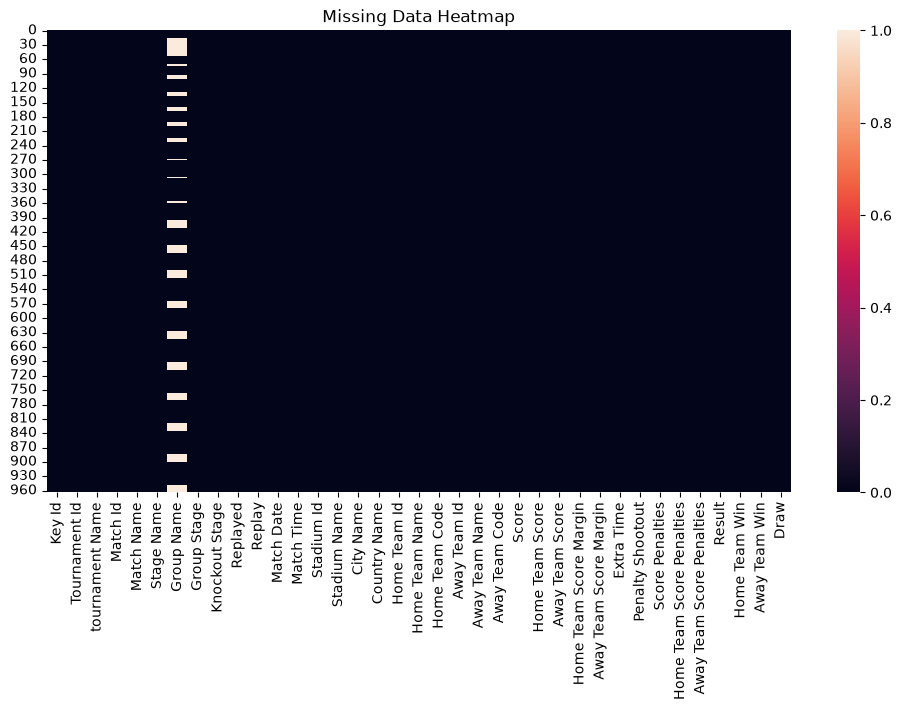

In [11]:
df_check = df.replace("not applicable", np.nan)

plt.figure(figsize=(12, 6))
sns.heatmap(df_check.isnull())
plt.title("Missing Data Heatmap")
plt.show()

In [12]:
df['Score'].unique()

<StringArray>
[   '4–1',    '3–0',    '2–1',    '3–1',    '1–0',    '4–0',    '6–3',
    '6–1',    '4–2',    '3–2',    '5–2',    '7–1',    '1–1',    '3–3',
    '6–0',    '6–5',    '2–0',    '8–0',    '5–1',    '2–2',    '5–0',
    '9–0',    '4–4',    '7–0',    '8–3',    '7–2',    '7–5',    '1–3',
    '7–3',    '0–0',    '5–3', 'Jan-00',    '0–1',    '4–3',    '0–2',
    '0–3',    '0–7',    '1–4',    '1–2',    '1–5',   '10–1',    '2–3',
    '3–4',    '2–4',    '0–4',    '2–5',    '1–7',    '6–2']
Length: 48, dtype: str

In [13]:
df[df['Score'] == "Jan-00"]

,Key Id,Tournament Id,tournament Name,Match Id,Match Name,Stage Name,Group Name,Group Stage,Knockout Stage,Replayed,...,Away Team Score Margin,Extra Time,Penalty Shootout,Score Penalties,Home Team Score Penalties,Away Team Score Penalties,Result,Home Team Win,Away Team Win,Draw
217,218,WC-1970,1970 FIFA World Cup,M-1970-18,Sweden v Uruguay,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


In [14]:
df.loc[df['Score'] == 'Jan-00', 'Score'] = '1-0'

**Step 3: Total Goals per Match**

In [15]:
df['Total_Goals'] = df['Home Team Score'] + df['Away Team Score']
df[['Home Team Score', 'Away Team Score', 'Total_Goals']].head()

,Home Team Score,Away Team Score,Total_Goals
0,4,1,5
1,3,0,3
2,2,1,3
3,3,1,4
4,1,0,1


**Step 4: Trend Analysis Average Goals per Match by Year**

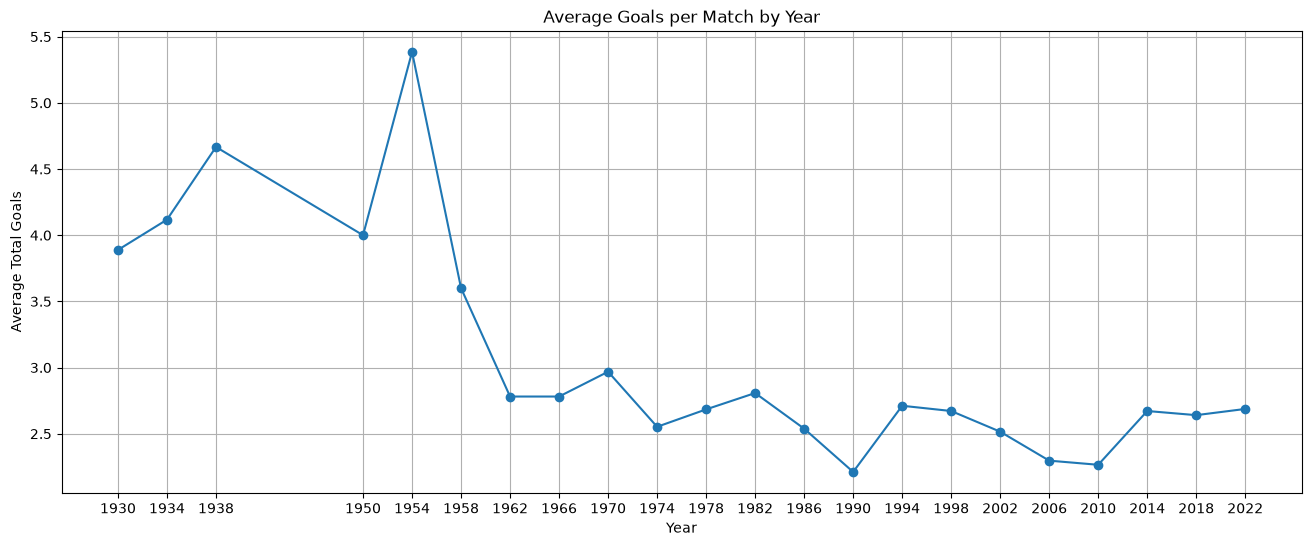

In [27]:
df['Year'] = df['Tournament Id'].str.split('-').str[1].astype(int)
yearly_goals = df.groupby('Year')['Total_Goals'].mean()

yearly_goals.plot(marker='o', title='Average Goals per Match by Year', grid=True, figsize=(16, 6), xticks=yearly_goals.index)
plt.xlabel('Year')
plt.ylabel('Average Total Goals')
plt.show()

**Step 5: Top 10 Teams by Total Goals Scored**

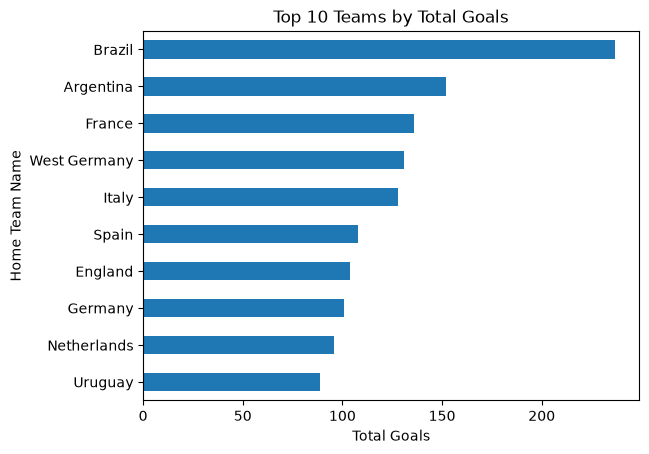

In [17]:
home_goals = df.groupby('Home Team Name')['Home Team Score'].sum()
away_goals = df.groupby('Away Team Name')['Away Team Score'].sum()
team_goals = (home_goals + away_goals).sort_values(ascending=False)

top10 = team_goals.head(10)
top10.sort_values().plot(kind='barh', title='Top 10 Teams by Total Goals')
plt.xlabel('Total Goals')
plt.show()

**Step 6: Outlier Detection (IQR)**

Note: this dataset has no 'Attendance' column, so outlier analysis is done on 'Total_Goals' only.

In [18]:
df['Total_Goals'].describe()

count    964.000000
mean       2.821577
std        1.927371
min        0.000000
25%        1.000000
50%        3.000000
75%        4.000000
max       12.000000
Name: Total_Goals, dtype: float64

The max value is 4x the 75th percentile value - Definitely outliers.

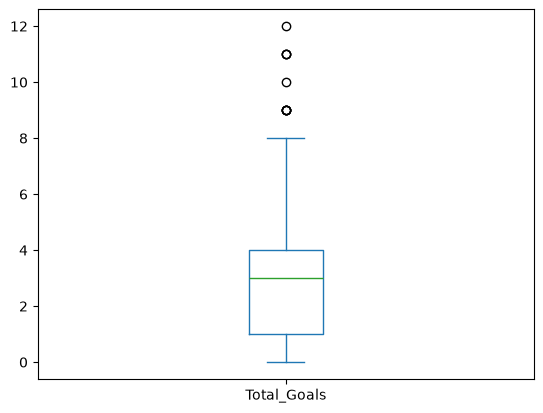

In [19]:
df['Total_Goals'].plot(kind='box')
plt.show()

In [20]:
def find_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

goal_outliers = find_outliers(df, 'Total_Goals')
print("Total_Goals outliers:", len(goal_outliers))

Total_Goals outliers: 10


**Step 7: Summary**

- The dataset is clearner and has no null values. 


   - Other than the fact that it has there is 'not-applicable' (252 values) in 'Group Name' column.


   - There is a excel auto-conversion problem - Score column had 'Jan-00' instead of 1-0, fixed it.

- Goals per match dropped over the years - 5.4 avg in 1954 to 2.5-2.7 now. Game got more defensive.


- Brazil is the top scorer overall (237 goals), then Argentina, France.


- No Attendance column, so outliers checked only on Total_Goals - IQR found 10 high scoring outlier matches.